<a href="https://colab.research.google.com/github/vishrutbhushan/LearnTo/blob/main/1.Vector_RAG/01_vector_rag_limitations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On Agentic GraphRAG
# Notebook 1: Vector RAG and Its Limitations

---
**Workshop series:** Agentic GraphRAG for Autonomous Incident Investigation  
**Prerequisites:** Python basics, familiarity with JSON  
**Runtime:** Google Colab — CPU only, no GPU required  

---

## Introduction

### The Problem: Incident Investigation Takes Too Long

Imagine you are the on-call engineer at 2 AM. Your monitoring system fires an alert: login failures are spiking. Users cannot authenticate. Every second of downtime costs revenue and trust.

You open your terminal and start asking questions:

- *What changed recently — any deployments?*
- *Which team owns the broken service, and who is the on-call contact?*
- *What other services depend on this one?
- *Have we seen this failure pattern before? What fixed it last time?*

The answers are scattered across five or six different systems: a runbook wiki, a service catalog, a CI/CD deployment log, a dependency map, and previous incident reports. You open each one manually, copy-paste information into a shared doc, and piece the story together yourself. This process, under pressure, takes 30 to 60 minutes before you even begin a fix.

**This is the problem that Agentic GraphRAG solves.**

### The Vision: Autonomous Incident Investigation

An Agentic GraphRAG system connects all of those knowledge sources into a single structured graph, then uses an LLM to reason over that graph in response to natural-language questions. Instead of searching five tools, an engineer asks one question and gets a grounded, traceable answer:

> *"The root cause of INC-003 was a compounding latency effect between Auth Service v2.1 (deployed April 10 by Alice, Identity Team) and API Gateway v3.2.1 (deployed April 11 by David, Platform Team)."*

That answer requires traversing ownership links, reading deployment timestamps, cross-referencing incident records, and synthesizing across the entire knowledge base. No simple search engine can do it.

We start with Vector RAG — not because it is the right tool for this problem, but because understanding *why* it fails is the clearest possible motivation for everything that comes after.

---

## The Knowledge Base

The dataset models a real-world SRE knowledge base for a four-service authentication platform. All incident-relevant information is split across six JSON files, each representing a different type of operational knowledge.

| File | What it contains | Why it matters for incident investigation |
|---|---|---|
| `system.json` | Descriptions of each microservice — what it does, how it behaves, version-specific changes | Understand what a service is responsible for |
| `ownership.json` | Which team owns which service and their responsibilities | Know who to contact when something breaks |
| `team_members.json` | Individual engineers in each team | Identify the specific people to page |
| `dependencies.json` | Which service calls which other service | Calculate blast radius — what else breaks when one service fails |
| `deployment_events.json` | Deployment history with timestamps, versions, and change descriptions | Correlate changes with incident windows |
| `past_incidents.json` | Incident reports: symptoms, affected services, root cause, resolution steps | Learn from past failures |

Together these six files contain everything an engineer would normally search for manually during an incident. The challenge is that a real answer requires joining across *multiple* files simultaneously.

---

## Setup

Install the three packages needed for this notebook.

In [1]:
!pip install -q faiss-cpu sentence-transformers matplotlib google-genai
print("Packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 67.5 MB/s eta 0:00:00
Packages installed.


In [2]:
import json
import numpy as np
import faiss
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sentence_transformers import SentenceTransformer
from pathlib import Path

print("Libraries ready.")

Libraries ready.


---

## Credentials — Gemini API Key and Hugging Face Token

This notebook uses two external services. You need to obtain a key for each and store them in **Colab Secrets** before running any cell that calls a model.

---

### Gemini API Key

Gemini is Google's LLM family. We use **Gemini 2.0 Flash** in this notebook for the generation step. The free tier is sufficient for all workshop exercises.

**How to create a Gemini API key:**

1. Go to [Google AI Studio](https://aistudio.google.com/app/apikey) — sign in with a Google account
2. Click **Create API key**
3. Select an existing Google Cloud project or create a new one
4. Copy the generated key

---

### Hugging Face Token

Sentence-transformers downloads embedding models directly from the Hugging Face Hub. The model used here (`all-MiniLM-L6-v2`) is public, so a token is not strictly required — but setting one avoids anonymous rate limits and is required for any gated or private model.

**How to create a Hugging Face token:**

1. Create a free account at [huggingface.co](https://huggingface.co) if you do not have one
2. Click your profile picture → **Settings** → **Access Tokens**
3. Click **New token** → give it a name → select **Read** role
4. Click **Generate a token** and copy the value

---

### Adding Both Keys to Colab Secrets

Colab Secrets stores keys securely and makes them available to your notebook without exposing them in the source code.

1. Click the **key icon** in the left sidebar (or go to **Tools → Secrets**)
2. Click **Add new secret**
3. Name: `GOOGLE_API_KEY` — Value: paste your Gemini key → toggle **Notebook access ON**
4. Repeat for `HF_TOKEN` — Value: paste your Hugging Face token → toggle **Notebook access ON**

The cell below reads both secrets and configures the clients.

In [6]:
import os

# ── Colab / local credentials ───────────────────
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')
    HF_TOKEN       = userdata.get('HF_TOKEN')
    print("Credentials loaded from Colab Secrets.")
except Exception:
    GEMINI_API_KEY = os.getenv('GOOGLE_API_KEY', '')
    HF_TOKEN       = os.getenv('HF_TOKEN', '')
    print("Colab Secrets not available. Reading from environment variables.")

# ── HF token for embeddings ─────────────────────
if HF_TOKEN:
    os.environ['HUGGINGFACE_HUB_TOKEN'] = HF_TOKEN

# ── NEW Gemini SDK (IMPORTANT) ───────────────────
from google import genai

client = genai.Client(api_key=GEMINI_API_KEY)

print("Gemini client configured.")
print("HuggingFace token set." if HF_TOKEN else "HuggingFace token not set (fine for public models).")

Credentials loaded from Colab Secrets.
Gemini client configured.
HuggingFace token set.


---

## Exploring the Data

The knowledge base is distributed as a single zip file (`data.zip`) that contains all six JSON files. The cell below downloads and extracts it at runtime so the notebook is fully self-contained in Google Colab.

After extraction, we load each file and inspect one representative example from each — giving you a concrete mental model of the data before building anything on top of it.

In [8]:
import zipfile
from pathlib import Path
import shutil
import urllib.request

REPO_RAW_BASE = "https://raw.githubusercontent.com/AmmarMohanna/oreilly-agentic-graphrag/main"
RUNTIME_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
ZIP_PATH = RUNTIME_DIR / "data.zip"
DATA_DIR = RUNTIME_DIR / "data"

# Make Lab 1 self-contained in Colab. Opening a notebook from GitHub does not
# automatically copy data.zip into /content, so fetch it if needed.
if not ZIP_PATH.exists():
    local_zip = Path("data.zip")
    if local_zip.exists():
        shutil.copy(local_zip, ZIP_PATH)
        print(f"Copied {local_zip} -> {ZIP_PATH}")
    else:
        url = f"{REPO_RAW_BASE}/1.Vector_RAG/data.zip"
        print(f"Downloading {url}")
        urllib.request.urlretrieve(url, ZIP_PATH)
        print(f"Saved {ZIP_PATH}")

if not DATA_DIR.exists():
    print("Extracting data.zip ...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(RUNTIME_DIR)
    print("Extracted.")
else:
    print("data/ folder already present, skipping extraction.")

files = sorted(DATA_DIR.glob("*.json"))
expected = {
    "dependencies.json",
    "deployment_events.json",
    "ownership.json",
    "past_incidents.json",
    "system.json",
    "team_members.json",
}
found = {f.name for f in files}
missing = sorted(expected - found)
print(f"Files in data/: {[f.name for f in files]}")
if missing:
    raise FileNotFoundError(f"Missing required data files: {missing}")


Saved /content/data.zip
Extracting data.zip ...
Extracted.
Files in data/: ['dependencies.json', 'deployment_events.json', 'ownership.json', 'past_incidents.json', 'system.json', 'team_members.json']


### File 1 — `system.json`

Contains fact sentences about each microservice. Each key is a service name; the value is a list of sentences describing its role, behavior, and version-specific changes.

We look at the **Auth Service** entry as an example.

In [9]:
with open(DATA_DIR / 'system.json') as f:
    system_data = json.load(f)

print(f"Services: {list(system_data.keys())}")
print(f"Total fact sentences: {sum(len(v) for v in system_data.values())}")
print()
print("--- Example: Auth Service ---")
for fact in system_data['Auth Service']:
    print(f"  {fact}")

Services: ['Auth Service', 'API Gateway', 'Database Service', 'Cache Service']
Total fact sentences: 20

--- Example: Auth Service ---
  Auth Service handles authentication and issues secure tokens for API Gateway requests with JWT-based session management.
  Auth Service also enforces token expiration rules and refresh token validation logic.
  Auth Service v2.1 introduced stricter token validation and refresh token rotation enforcement.
  Auth Service v2.0.3 applies standard token validation without rotation policy.
  Auth Service is the core login component and all user authentication requests flow through it.
  Authentication failures in Auth Service directly cause login disruptions for all platform users.
  Auth Service maintains session state and communicates token validity to downstream services.


### File 2 — `ownership.json`

Maps each team to the service it owns, along with responsibility and escalation statements. This is the ownership layer that answers *"who do I call?"*

Example: the **Identity Team** entry.

In [10]:
with open(DATA_DIR / 'ownership.json') as f:
    ownership_data = json.load(f)

print(f"Teams: {list(ownership_data.keys())}")
print()
print("--- Example: Identity Team ---")
for fact in ownership_data['Identity Team']:
    print(f"  {fact}")

Teams: ['Identity Team', 'Platform Team', 'Data Engineering Team', 'Infrastructure Team']

--- Example: Identity Team ---
  Identity Team owns Auth Service and is responsible for authentication flow stability, token security, and login reliability.
  Identity Team is the primary escalation contact for any issues related to token validation, session management, or login failures.
  Identity Team responds to all Auth Service incidents and coordinates rollback decisions for authentication components.


### File 3 — `team_members.json`

Lists the individual engineers in each team. This is the final hop in a three-step chain: *service -> owning team -> specific engineers to page.*

Example: the **Identity Team** members.

In [11]:
with open(DATA_DIR / 'team_members.json') as f:
    team_members_data = json.load(f)

print(f"Teams with listed members: {list(team_members_data.keys())}")
print()
print("--- Example: Identity Team members ---")
for entry in team_members_data['Identity Team']:
    print(f"  {entry}")

Teams with listed members: ['Identity Team', 'Platform Team', 'Data Engineering Team', 'Infrastructure Team']

--- Example: Identity Team members ---
  Identity Team: Alice, Omar, Lina are Auth Service maintainers and authentication logic owners.


### File 4 — `dependencies.json`

Records which services call which other services. The dependency graph shapes the blast radius of any failure.

The full call graph is:
```
API Gateway  -->  Auth Service  -->  Database Service
                               -->  Cache Service  -->  Database Service
```

Example: **Auth Service** dependencies.

In [12]:
with open(DATA_DIR / 'dependencies.json') as f:
    dependencies_data = json.load(f)

print(f"Services with declared dependencies: {list(dependencies_data.keys())}")
print()
print("--- Example: Auth Service dependencies ---")
for fact in dependencies_data['Auth Service']:
    print(f"  {fact}")

Services with declared dependencies: ['API Gateway', 'Auth Service', 'Cache Service']

--- Example: Auth Service dependencies ---
  Auth Service depends on Database Service for verifying hashed credentials and retrieving user profiles.
  Auth Service uses Cache Service to validate active sessions quickly before querying Database to reduce latency spikes.


### File 5 — `deployment_events.json`

Deployment history grouped by team, with timestamps, versions, and change descriptions. This is the temporal layer: correlating what changed with when incidents started.

The critical window is April 10-11, 2026. Two deployments during this window combined to produce all three incidents.

Example: **Platform Team** deployment entries.

In [13]:
with open(DATA_DIR / 'deployment_events.json') as f:
    deployment_data = json.load(f)

print(f"Teams with deployment records: {list(deployment_data.keys())}")
print()
print("--- Example: Platform Team deployments ---")
for event in deployment_data['Platform Team']:
    print(f"  {event}")

Teams with deployment records: ['Identity Team', 'Data Engineering Team', 'Infrastructure Team', 'Platform Team']

--- Example: Platform Team deployments ---
  2026-04-11 08:30 Platform Team (David) deployed API Gateway v3.2.1 modifying routing logic for authentication flow and request prioritization.
  2026-04-11 08:45 Platform Team (Sara) enabled adaptive rate limiting for login endpoints under high traffic conditions.
  API Gateway v3.2.1 altered the order in which authentication requests were prioritized in the routing queue.
  The combination of Auth Service v2.1 stricter validation and API Gateway v3.2.1 new routing caused compounding latency on the authentication path.


### File 6 — `past_incidents.json`

Three incident reports (INC-001 to INC-003) documenting symptoms, affected services, root causes, and resolution steps. INC-003 is the most severe: a total login failure affecting all users for 22 minutes.

Example: **INC-003**, the most complex incident — the one that requires multi-source reasoning to fully explain.

In [14]:
with open(DATA_DIR / 'past_incidents.json') as f:
    incidents_data = json.load(f)

print(f"Incidents recorded: {list(incidents_data.keys())}")
print()
print("--- Example: INC-003 ---")
for fact in incidents_data['INC-003']:
    print(f"  {fact}")

Incidents recorded: ['INC-001', 'INC-002', 'INC-003']

--- Example: INC-003 ---
  System-wide login failures occurred across all services during the incident window from 09:50 to 10:12.
  Users were completely unable to log in during INC-003 as authentication requests failed at every layer.
  Login failure rate spiked to near 100% during the peak of the incident affecting all authenticated endpoints.
  Authentication failures cascaded from token validation errors through session validation and into API Gateway retries.
  Session validation failures caused active user sessions to expire and new login attempts to be rejected.
  The login disruption affected all services depending on Auth Service for user identity verification.
  System-wide login failures occurred due to cascading latency across API Gateway, Auth Service, and Database Service after multiple concurrent deployments.
  Authentication flow degraded, causing session validation failures, increased retry traffic, and user login

---

## Vector RAG

### How It Works

Vector RAG is the standard RAG pattern. It has two phases:

**Indexing (done once, offline)**
1. Extract every sentence from every document into a flat list
2. Encode each sentence into a dense vector using a sentence embedding model
3. Store all vectors in a vector database

**Querying (at inference time)**
1. Encode the user question using the same model
2. Find the top-k most similar vectors in the database (cosine similarity)
3. Return those sentences as context to an LLM

The diagram below shows the full pipeline.

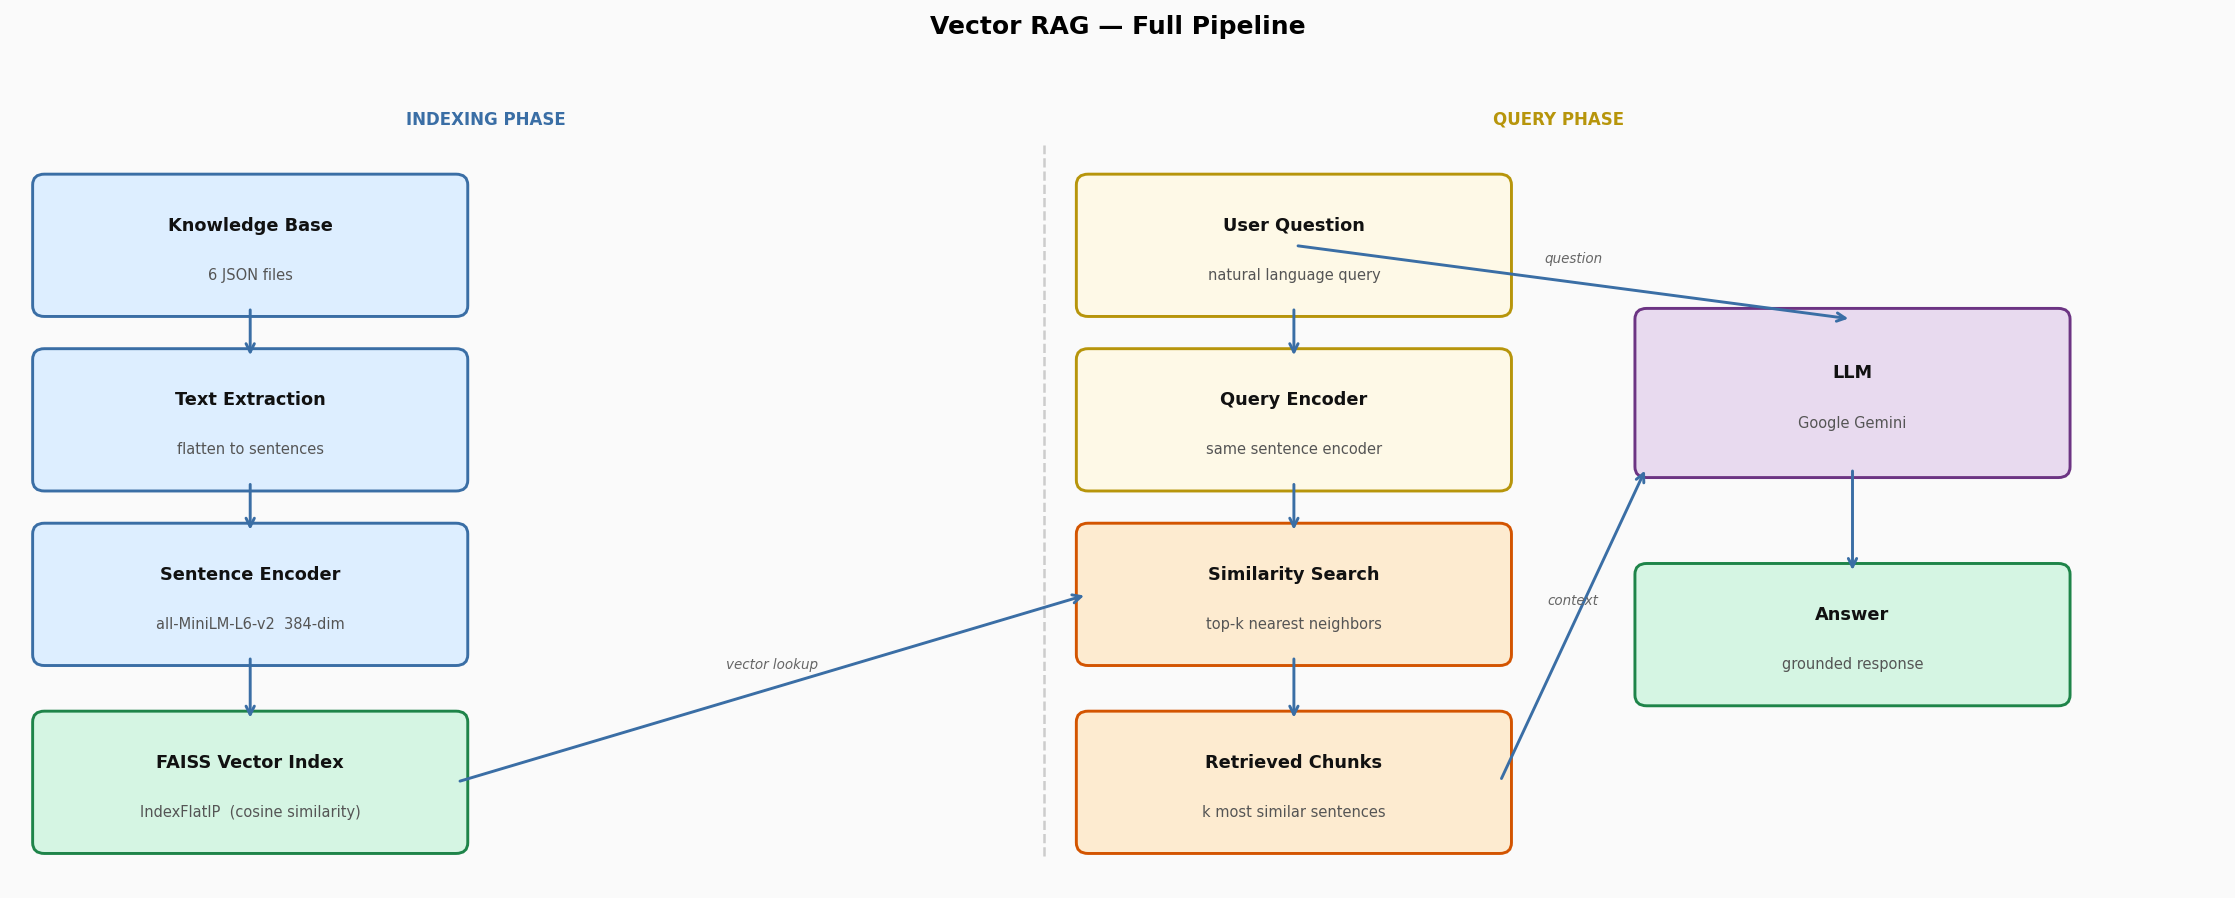

### Build the Flat Corpus

Vector RAG flattens every file into a single unordered list of sentences. At this step, all structural information — file groupings, key-value relationships, ownership links — is discarded. The sentences from `system.json`, `ownership.json`, and `past_incidents.json` are all mixed together with no memory of where they came from or how they relate.

In [15]:
corpus = []

for facts in system_data.values():
    corpus.extend(facts)

for facts in ownership_data.values():
    corpus.extend(facts)

for entries in team_members_data.values():
    corpus.extend(entries)

for deps in dependencies_data.values():
    corpus.extend(deps)

for events in deployment_data.values():
    corpus.extend(events)

for facts in incidents_data.values():
    corpus.extend(facts)

print(f"Total sentences in corpus: {len(corpus)}")
print()
print("Sample — first 4 sentences (structure is now gone):")
for i, s in enumerate(corpus[:4], 1):
    print(f"  [{i}] {s}")

Total sentences in corpus: 71

Sample — first 4 sentences (structure is now gone):
  [1] Auth Service handles authentication and issues secure tokens for API Gateway requests with JWT-based session management.
  [2] Auth Service also enforces token expiration rules and refresh token validation logic.
  [3] Auth Service v2.1 introduced stricter token validation and refresh token rotation enforcement.
  [4] Auth Service v2.0.3 applies standard token validation without rotation policy.


### Embed and Index

We encode every sentence into a 384-dimensional vector with `all-MiniLM-L6-v2` and store it in a FAISS flat index. L2 normalization converts inner product search into cosine similarity search.

In [16]:
print("Loading sentence encoder (first run downloads ~80 MB)...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding corpus...")
embeddings = embedder.encode(
    corpus, show_progress_bar=True, convert_to_numpy=True
).astype('float32')

faiss.normalize_L2(embeddings)

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

print(f"\nIndex: {index.ntotal} vectors  |  {embeddings.shape[1]} dimensions")


Loading sentence encoder (first run downloads ~80 MB)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding corpus...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]


Index: 71 vectors  |  384 dimensions


---

## Retrieval

We create a function to retrieve relevant nodes and relationships from the graph based on the user query, enabling multi-hop reasoning and context assembly for downstream generation.

In [17]:
def retrieve(question: str, k: int = 5):
    q = embedder.encode([question], convert_to_numpy=True).astype('float32')
    faiss.normalize_L2(q)
    scores, ids = index.search(q, k)
    return [(round(float(scores[0][i]), 3), corpus[ids[0][i]]) for i in range(k)]


print("Retrieval ready.")

Retrieval ready.


---

## Generation

We use a large language model to synthesize the retrieved GraphRAG context into a final answer, combining entities, relationships, and evidence paths into a coherent response.

In [18]:
response = client.models.generate_content(
    model='gemini-3-flash-preview',
    contents="Explain Agentic GraphRAG in simple terms."
)

print(response.text)

To understand **Agentic GraphRAG**, let’s break it down into three simple layers.

### 1. The Foundation: What is RAG?
Imagine you ask an AI a question about your company’s private handbook. The AI wasn't trained on that handbook, so it uses **RAG (Retrieval-Augmented Generation)**.
*   **The Analogy:** It’s like giving the AI a search engine. When you ask a question, the AI looks through its "filing cabinet" (your documents), finds the right page, reads it, and summarizes the answer for you.
*   **The Problem:** Standard RAG is good at finding specific facts, but it’s bad at seeing the "big picture" or connecting dots across different documents.

### 2. The Upgrade: What is GraphRAG?
Standard RAG treats text like a long list of sentences. **GraphRAG** turns those documents into a **Knowledge Graph** (a map of nodes and links).
*   **The Analogy:** Instead of a filing cabinet, the AI now has a **Mind Map**. It knows that "Project X" is connected to "Sarah," and "Sarah" is the expert on

---

## Retrieval-Augmented Generation [Full Pipeline]


We now run the full RAG pipeline end-to-end. For each question, the `vector_rag()` function below:

1. **Retrieves** the top-k most similar sentences from the FAISS index (cosine similarity)
2. **Augments** the prompt by injecting those sentences as grounded context
3. **Generates** a natural-language answer with Gemini 2.0 Flash, strictly limited to what the context contains

We run it against all four query types — local, multi-hop, and global synthesis — so you can compare the retrieved context and the generated answer side-by-side for each one.

In [19]:
def vector_rag(question: str, k: int = 5) -> None:
    """
    Full Vector RAG pipeline: Retrieve -> Augment -> Generate.
    Prints retrieved chunks and Gemini-generated answer.
    """

    divider = "=" * 72

    print(divider)
    print(f"QUESTION: {question}")
    print(divider)

    # ── 1. Retrieval ─────────────────────────────────────────────
    chunks = retrieve(question, k)

    print(f"\nRETRIEVED CONTEXT (top {k} ranked by cosine similarity)")
    print("-" * 72)

    for rank, (score, sentence) in enumerate(chunks, 1):
        print(f"  Rank {rank}  |  score {score:.3f}  |  {sentence}")

    # ── 2. Augmentation ──────────────────────────────────────────
    context = "\n".join(f"- {sentence}" for _, sentence in chunks)

    prompt = (
        "You are an expert SRE assistant.\n"
        "Answer ONLY using the context below.\n"
        "If the context is insufficient, say so explicitly.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n\n"
        "Answer:"
    )

    # ── 3. Generation (NEW Gemini SDK) ───────────────────────────
    response = client.models.generate_content(
        model='gemini-3-flash-preview',
        contents=prompt
    )

    print(f"\nGEMINI OUTPUT")
    print("-" * 72)
    print(response.text)
    print(divider)


print("vector_rag() ready.")

vector_rag() ready.


In [20]:
# Query 1 — Local Lookup
# The answer exists as a direct sentence in the corpus. Retrieval should be clean.

vector_rag(
    "What does the Auth Service do?",
    k=3
)

QUESTION: What does the Auth Service do?

RETRIEVED CONTEXT (top 3 ranked by cosine similarity)
------------------------------------------------------------------------
  Rank 1  |  score 0.759  |  Auth Service is the core login component and all user authentication requests flow through it.
  Rank 2  |  score 0.724  |  Auth Service depends on Database Service for verifying hashed credentials and retrieving user profiles.
  Rank 3  |  score 0.662  |  Auth Service maintains session state and communicates token validity to downstream services.

GEMINI OUTPUT
------------------------------------------------------------------------
The Auth Service is the core login component through which all user authentication requests flow. It verifies hashed credentials, retrieves user profiles, maintains session state, and communicates token validity to downstream services.


In [21]:
# Query 2 — Multi-hop Reasoning
# Requires: API Gateway -> depends on -> Auth Service -> owned by -> Identity Team -> members -> Alice, Omar, Lina
# The chain is broken when data is flattened. Retrieved chunks cover individual hops but not the connection.

vector_rag(
    "Which team owns the service that API Gateway depends on?",
    k=5
)

QUESTION: Which team owns the service that API Gateway depends on?

RETRIEVED CONTEXT (top 5 ranked by cosine similarity)
------------------------------------------------------------------------
  Rank 1  |  score 0.817  |  Platform Team owns API Gateway and manages request routing, traffic shaping, and API security enforcement.
  Rank 2  |  score 0.698  |  API Gateway is the entry point for all user-facing requests and controls traffic flow to backend services.
  Rank 3  |  score 0.690  |  API Gateway depends on Auth Service for authentication decisions and user identity verification.
  Rank 4  |  score 0.655  |  Platform Team is responsible for all routing configuration changes and rate limiting policies at the API Gateway layer.
  Rank 5  |  score 0.603  |  API Gateway includes request throttling and basic security filtering before forwarding traffic.

GEMINI OUTPUT
------------------------------------------------------------------------
The context is insufficient to determine whic

In [22]:
# Query  — Global Synthesis
# Requires reading all three incident records simultaneously and identifying the common pattern.
# Top-k retrieval returns only the most textually similar sentences, not a full cross-incident scan.

vector_rag(
    "What is the common root cause pattern across all three incidents, and which service is the single point of failure?",
    k=5
)

QUESTION: What is the common root cause pattern across all three incidents, and which service is the single point of failure?

RETRIEVED CONTEXT (top 5 ranked by cosine similarity)
------------------------------------------------------------------------
  Rank 1  |  score 0.501  |  System-wide login failures occurred across all services during the incident window from 09:50 to 10:12.
  Rank 2  |  score 0.407  |  Login failure rate spiked to near 100% during the peak of the incident affecting all authenticated endpoints.
  Rank 3  |  score 0.388  |  System-wide login failures occurred due to cascading latency across API Gateway, Auth Service, and Database Service after multiple concurrent deployments.
  Rank 4  |  score 0.380  |  Users experienced repeated login failures as their requests were dropped and retried by the gateway.
  Rank 5  |  score 0.364  |  Platform Team handles escalations related to dropped requests, routing anomalies, and gateway-level throttling.

GEMINI OUTPUT
----

---

## Summary

What types of failures have you noticed?

| Query type | Retrieval | Generation (Gemini) | Root reason |
|---|---|---|---|
| Local fact lookup | Correct chunks | Correct answer | One sentence directly matches the question |
| Multi-hop reasoning | Fragmented chunks | Incomplete or hallucinated | The relationship chain is destroyed during flattening |
| Global synthesis | Partial chunks | Misses the pattern | Top-k reads a slice, not the whole corpus |

**The retriever is the bottleneck, not the model.** A better LLM does not fix bad retrieval. Gemini is grounded strictly in what is passed to it — if the context is missing the connecting links, no amount of model capability can reconstruct them.

**What comes next — Notebook 2: Introduction to Knowledge Graphs**

Notebook 2 rebuilds the same knowledge base as a **property graph**. You will learn what a knowledge graph is, why it preserves the information that Vector RAG discards, and how to construct one from structured JSON data using NetworkX. Every ownership link, dependency edge, and deployment event becomes a typed, traversable relationship in the graph — exactly the structure needed to answer the queries that failed here.